# Section 4.2


In [43]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

from utils.log_print import LogPrint
from configs.base.env_cfg import device, torch_dtype
from utils.model_saver import (
    load_market_and_critic0,
    load_actor,
    load_critic_lambda
)
from utils.pricing.pvv_bs_model import PVVBSModel
from src.bs_model import sim_bs_paths_cfg

from src.data_processing import make_state_t
from src.rl_models import extract_theta_from_outputs

In [44]:
# =============================================================================
# Configuration
# =============================================================================

LOAD_DIR = "models/bs_0_2_mu_0_3"
LOAD_DIR = "models/4_2_bs_0_2"

ACTOR_LAMBDA = 100000.0

# Moneyness and maturity cross-sections
S_OVER_K_GRID = [0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2]
S_OVER_K_GRID = [0.8, 1.0, 1.2 , 1.6]
TAU_GRID = [0.05, 0.50]
LAMBDA_GRID = [
    # 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0,
    #            500.0, 1000.0,
    2500.0, 5000.0, 7500.0, 10000.0,
               25000.0, 50000.0,
    # 75000.0, 100000.0,
               # 1000000.0
]

In [45]:
# =============================================================================
# Load market, actor, critic0
# =============================================================================
log_print = LogPrint(
    print_debug=True,
    save_dir=os.path.join(LOAD_DIR, "logs"),
    prefix="analysis_section_4_1",
)
critic0, market_cfg, critic0_cfg, runtime_cfg = load_market_and_critic0(
    log_print=log_print,
    load_dir=LOAD_DIR,
    device=device,
    torch_dtype=torch_dtype,
)

actor, actor_cfg = load_actor(
    log_print=log_print,
    load_dir=LOAD_DIR,
    actor_lambda=ACTOR_LAMBDA,
    device=device,
    torch_dtype=torch_dtype,
)

actor.eval()
for p in actor.parameters():
    p.requires_grad_(False)


当前工作目录：/Users/hy/PycharmProjects/qlbs_rl
当前已是qlbs_rl根目录，无需切换
[MarketArtifactLoader] Loaded market artifact: 
path            : models/4_2_bs_0_2
  - MarketCFG   : market_cfg.json
  - Critic0     : critic0.pt
  - RuntimeCFG  : runtime_cfg.json

[ActorLoader] Loaded actor λ=100000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/actor.pt
  device: mps, dtype: torch.float32


In [46]:
# ============================================================
# Market config (BS)
# ============================================================

S0 = market_cfg.S0
mu = market_cfg.mu          # risk-neutral: mu = r
r = market_cfg.r
sigma = market_cfg.sigma

T = market_cfg.T
T_steps = market_cfg.T_steps
dt = market_cfg.dt

K = S0
option_type = market_cfg.option_type
transaction_cost_rate = market_cfg.transaction_cost_rate

# ============================================================
# Simulate BS paths
# ============================================================
N_paths = 50_000

S_paths_t, log_returns, _ = sim_bs_paths_cfg(
    s_cfg=market_cfg,
    N_paths=N_paths,
    T_steps=T_steps,
)

# torch -> numpy
S_paths = S_paths_t.cpu().numpy()

# ============================================================
# tau vector
# ============================================================
tau_vec = T - np.arange(T_steps + 1) * float(dt)
tau_vec = np.maximum(tau_vec, 1e-6)

# ============================================================
# BS benchmark price & delta (PVV)
# ============================================================
bs_pricer = PVVBSModel(market_cfg)

S_mat = S_paths[:, :-1]  # (N, T)
K_mat = np.full_like(S_mat, K)

price_mat, delta_mat_bs = bs_pricer.price_and_delta(
    S_mat=S_mat,
    K_mat=K_mat,
    tau_vec=tau_vec[:-1],
)

# assemble delta paths (including maturity)
delta_paths_bs = np.zeros_like(S_paths)
delta_paths_bs[:, :-1] = delta_mat_bs

if option_type == "call":
    delta_T = (S_paths[:, -1] > K).astype(float)
else:
    delta_T = -(S_paths[:, -1] < K).astype(float)

delta_paths_bs[:, -1] = delta_T
# ============================================================
# Initial option price (BS)
# ============================================================
initial_option_price = price_mat[:, 0].mean()


In [47]:
print(
    f'S0: {S0}, mu: {mu}, r: {r}, sigma: {sigma}, '
    f'T: {T}, T_steps: {T_steps}, dt: {dt}, K: {K}, '
    f'option_type: {option_type}, transaction_cost_rate: {transaction_cost_rate}'
)

S0: 100.0, mu: 0.3, r: 0.03, sigma: 0.2, T: 0.5, T_steps: 50, dt: 0.009999999776482582, K: 100.0, option_type: p, transaction_cost_rate: 0.0


[CriticLoader] Loaded critic λ=2500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_2500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=5000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_5000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=7500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_7500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=10000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_10000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=25000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_25000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=50000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_50000.0000.pt
  device: mps
S/K=0.80, tau=0.05
Theta0: mean=5.579e-04, std=3.463e-06
Theta1: mean=-9.438e-05, std=2.613e-05
Theta2: mean=-8.059e-04, std=1.217e-06


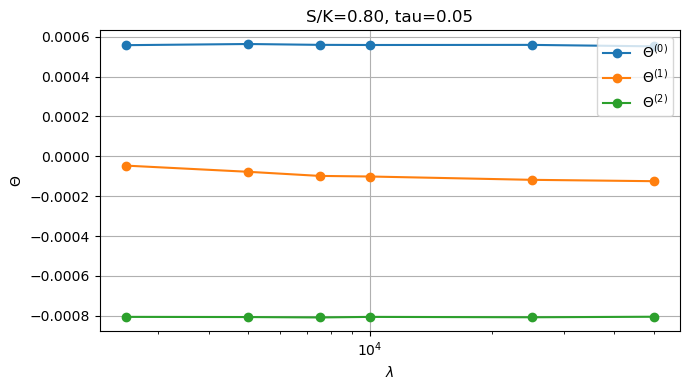

[CriticLoader] Loaded critic λ=2500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_2500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=5000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_5000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=7500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_7500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=10000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_10000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=25000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_25000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=50000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_50000.0000.pt
  device: mps
S/K=0.80, tau=0.50
Theta0: mean=4.173e-04, std=1.503e-05
Theta1: mean=-1.654e-04, std=2.620e-05
Theta2: mean=-8.097e-04, std=5.761e-06


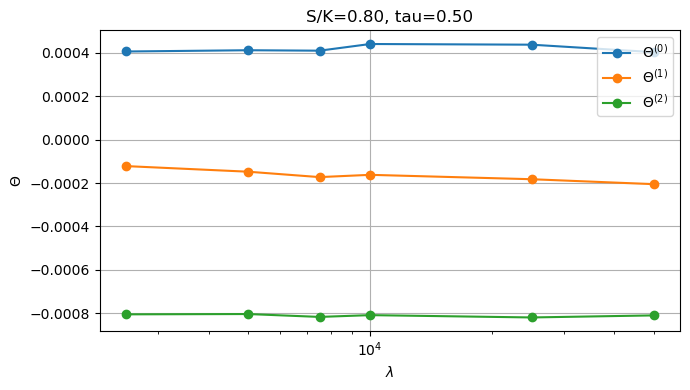

[CriticLoader] Loaded critic λ=2500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_2500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=5000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_5000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=7500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_7500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=10000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_10000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=25000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_25000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=50000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_50000.0000.pt
  device: mps
S/K=1.00, tau=0.05
Theta0: mean=2.448e-04, std=7.468e-06
Theta1: mean=-1.161e-04, std=8.577e-06
Theta2: mean=-8.053e-04, std=1.583e-06


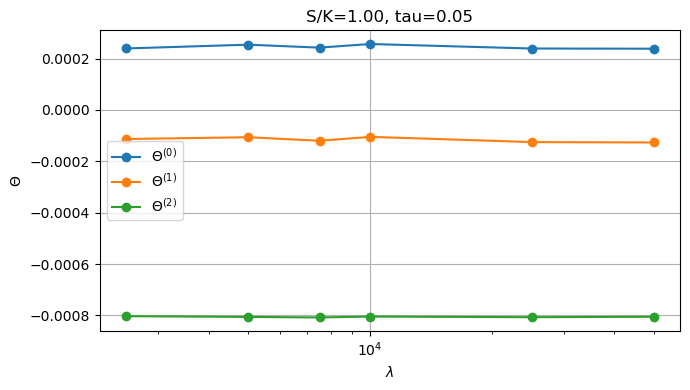

[CriticLoader] Loaded critic λ=2500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_2500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=5000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_5000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=7500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_7500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=10000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_10000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=25000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_25000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=50000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_50000.0000.pt
  device: mps
S/K=1.00, tau=0.50
Theta0: mean=1.768e-04, std=6.874e-06
Theta1: mean=-1.536e-04, std=8.271e-06
Theta2: mean=-8.070e-04, std=4.874e-06


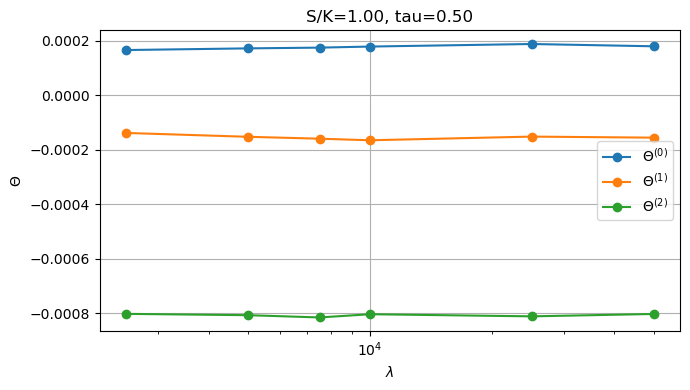

[CriticLoader] Loaded critic λ=2500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_2500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=5000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_5000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=7500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_7500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=10000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_10000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=25000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_25000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=50000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_50000.0000.pt
  device: mps
S/K=1.20, tau=0.05
Theta0: mean=-1.410e-06, std=6.400e-06
Theta1: mean=-1.780e-06, std=5.959e-06
Theta2: mean=-8.049e-04, std=2.397e-06


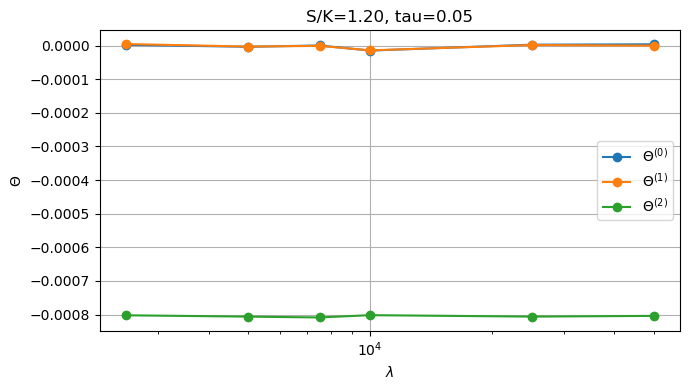

[CriticLoader] Loaded critic λ=2500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_2500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=5000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_5000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=7500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_7500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=10000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_10000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=25000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_25000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=50000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_50000.0000.pt
  device: mps
S/K=1.20, tau=0.50
Theta0: mean=3.276e-05, std=1.638e-05
Theta1: mean=-4.592e-05, std=1.716e-05
Theta2: mean=-8.058e-04, std=5.380e-06


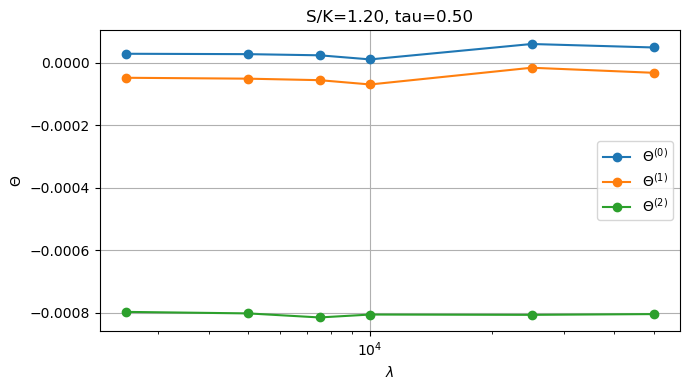

[CriticLoader] Loaded critic λ=2500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_2500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=5000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_5000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=7500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_7500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=10000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_10000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=25000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_25000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=50000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_50000.0000.pt
  device: mps
S/K=1.60, tau=0.05
Theta0: mean=2.108e-08, std=1.716e-06
Theta1: mean=6.051e-06, std=1.732e-06
Theta2: mean=-8.054e-04, std=2.847e-06


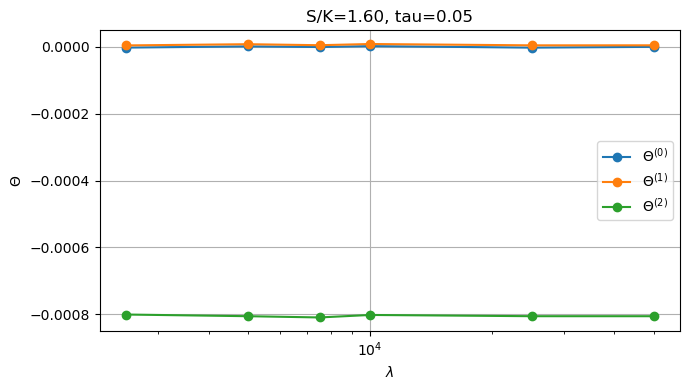

[CriticLoader] Loaded critic λ=2500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_2500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=5000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_5000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=7500.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_7500.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=10000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_10000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=25000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_25000.0000.pt
  device: mps
[CriticLoader] Loaded critic λ=50000.0
  path: models/4_2_bs_0_2/actor_lambda_100000.0000/critic_50000.0000.pt
  device: mps
S/K=1.60, tau=0.50
Theta0: mean=-1.838e-07, std=7.162e-06
Theta1: mean=1.107e-05, std=7.597e-06
Theta2: mean=-8.081e-04, std=7.138e-06


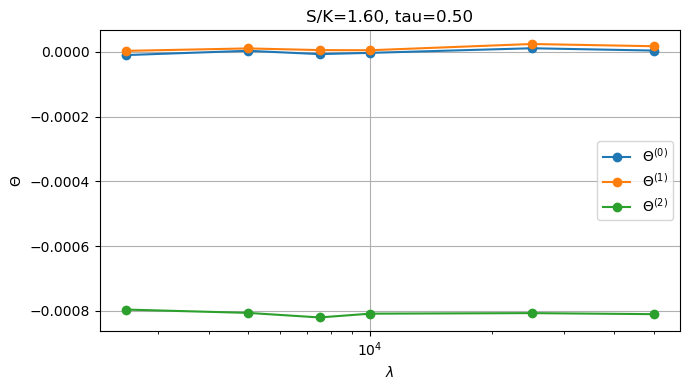

In [48]:
# =============================================================================
# Main experiment loop
# =============================================================================

results = []
results_all = []
for S_over_K in S_OVER_K_GRID:
    for tau in TAU_GRID:

        # -------------------------------------------------------------
        # Fixed state
        # -------------------------------------------------------------
        state = make_state_t(
            torch.tensor(S_over_K, device=device, dtype=torch_dtype),
            torch.tensor(tau, device=device, dtype=torch_dtype),
        )

        # Fixed action from actor
        with torch.no_grad():
            a = actor.mean(state)

        # Risk-neutral components
        with torch.no_grad():
            U0_0, U1_0 = critic0.heads(state)

        Theta0_list, Theta1_list, Theta2_list = [], [], []

        # -------------------------------------------------------------
        # Sweep lambda
        # -------------------------------------------------------------
        for lam in LAMBDA_GRID:
            critic, _ = load_critic_lambda(
                log_print=log_print,
                load_dir=LOAD_DIR,
                actor_lambda=ACTOR_LAMBDA,
                critic_lambda=lam,
                device=device,
                torch_dtype=torch_dtype,
            )

            with torch.no_grad():
                U1_0, U1_1, U1_2 = critic.heads(state)

            # Extract Theta estimates

            theta0, theta1, theta2 = extract_theta_from_outputs(
                u0_0=U0_0,
                u0_1=U1_0,
                u1_0=U1_0,
                u1_1=U1_1,
                u1_2=U1_2,
                risk_lambda=lam,
            )

            Theta0_list.append(float(theta0))
            Theta1_list.append(float(theta1))
            Theta2_list.append(float(theta2))

            results_all.append({
                "lambda": lam,
                "S_over_K": S_over_K,
                "tau": tau,
                "Theta0": float(theta0),
                "Theta1": float(theta1),
                "Theta2": float(theta2),
            })

        # -------------------------------------------------------------
        # Statistics
        # -------------------------------------------------------------
        Theta0_arr = np.array(Theta0_list)
        Theta1_arr = np.array(Theta1_list)
        Theta2_arr = np.array(Theta2_list)

        results.append({
            "S_over_K": S_over_K,
            "tau": tau,
            "Theta0_mean": Theta0_arr.mean(),
            "Theta0_std": Theta0_arr.std(),
            "Theta1_mean": Theta1_arr.mean(),
            "Theta1_std": Theta1_arr.std(),
            "Theta2_mean": Theta2_arr.mean(),
            "Theta2_std": Theta2_arr.std(),
        })

        # -------------------------------------------------------------
        # Print summary table row
        # -------------------------------------------------------------
        print("="*72)
        print(f"S/K={S_over_K:.2f}, tau={tau:.2f}")
        print(f"Theta0: mean={Theta0_arr.mean():.3e}, std={Theta0_arr.std():.3e}")
        print(f"Theta1: mean={Theta1_arr.mean():.3e}, std={Theta1_arr.std():.3e}")
        print(f"Theta2: mean={Theta2_arr.mean():.3e}, std={Theta2_arr.std():.3e}")
        print("="*72)

        # -------------------------------------------------------------
        # Plot Theta vs lambda
        # -------------------------------------------------------------
        plt.figure(figsize=(7,4))
        plt.plot(LAMBDA_GRID, Theta0_list, 'o-', label=r'$\Theta^{(0)}$')
        plt.plot(LAMBDA_GRID, Theta1_list, 'o-', label=r'$\Theta^{(1)}$')
        plt.plot(LAMBDA_GRID, Theta2_list, 'o-', label=r'$\Theta^{(2)}$')
        plt.xscale('log')
        plt.xlabel(r'$\lambda$')
        plt.ylabel(r'$\Theta$')
        plt.title(f"S/K={S_over_K:.2f}, tau={tau:.2f}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


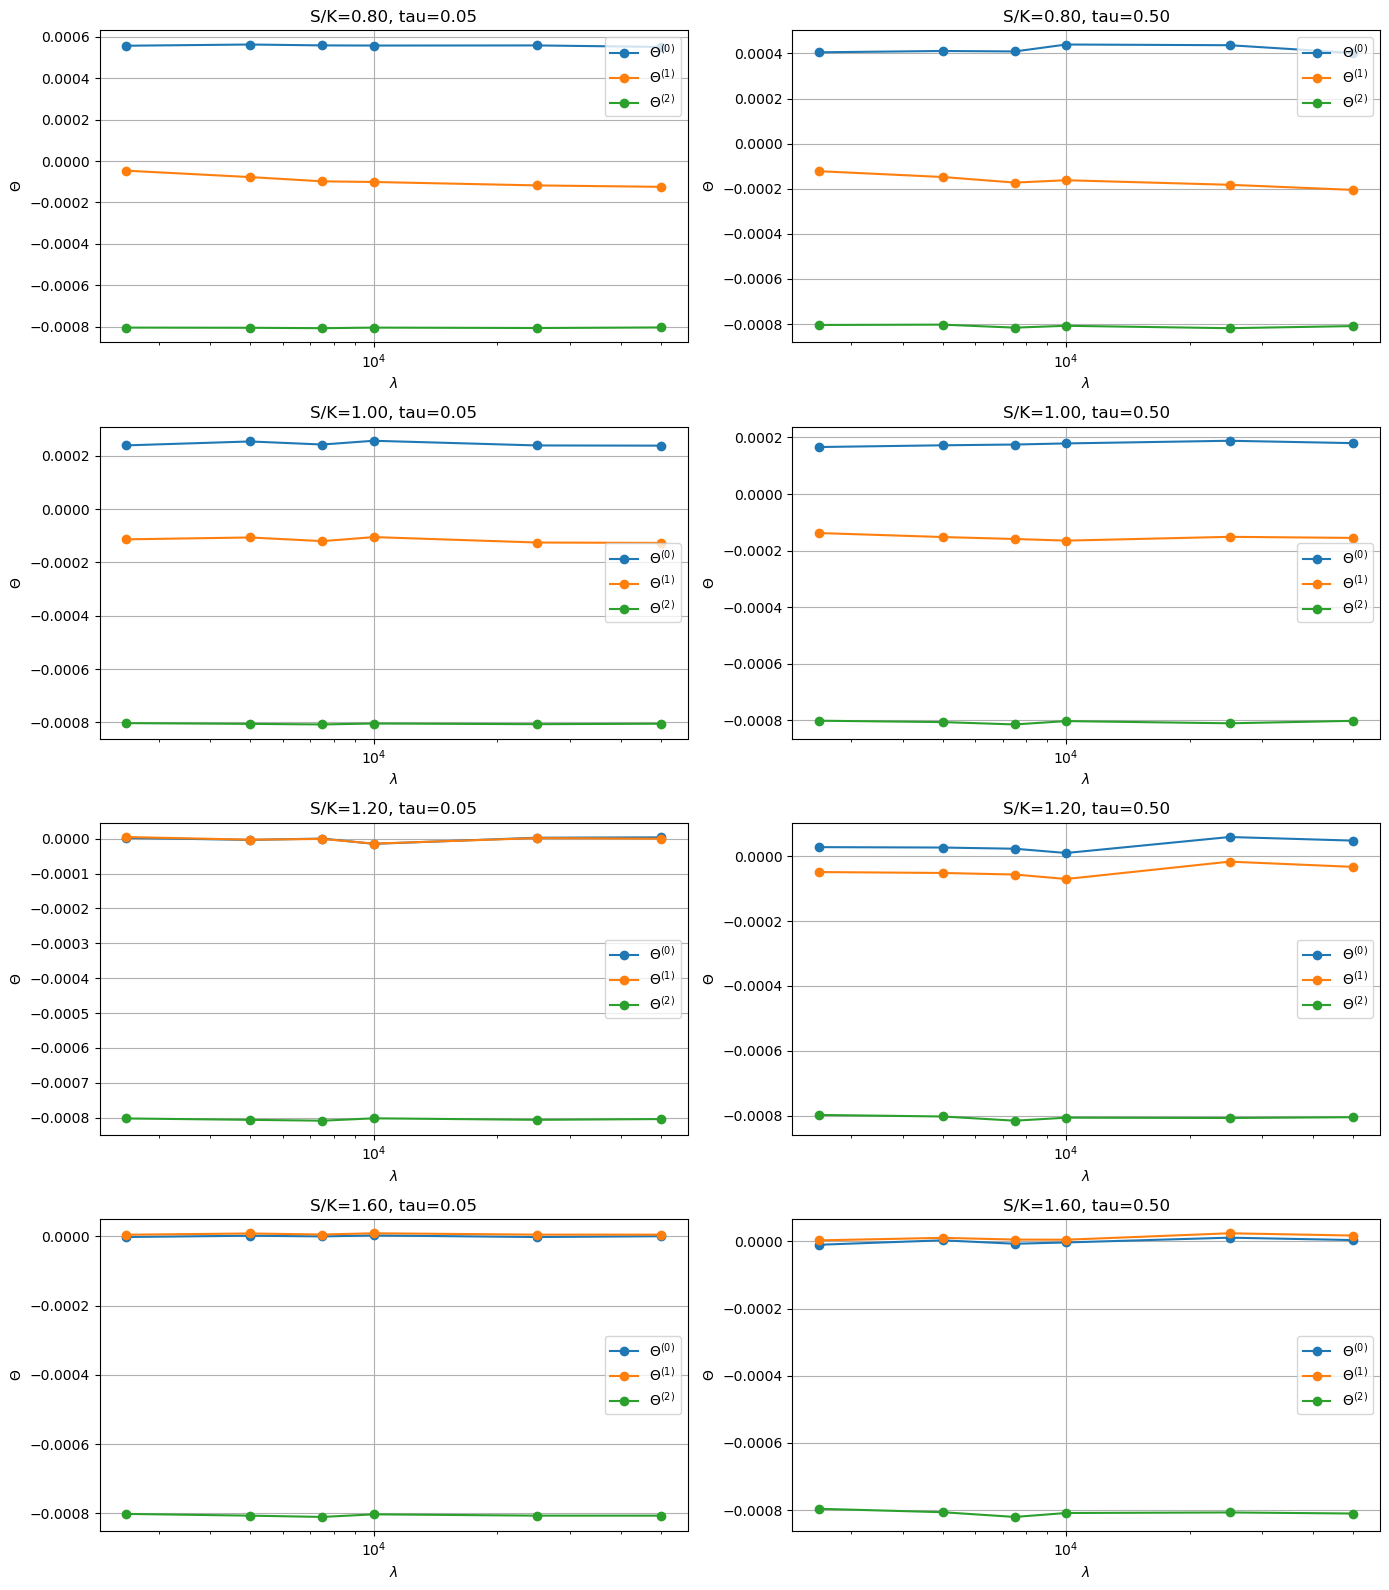

In [49]:
# -------------------------------------------------------------
# Plot Theta vs lambda (2 columns, multiple rows)
# -------------------------------------------------------------
import math
import pandas as pd
import matplotlib.pyplot as plt

df_all = pd.DataFrame(results_all)

n_plots = len(S_OVER_K_GRID) * len(TAU_GRID)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

plot_idx = 0

for S_over_K in S_OVER_K_GRID:
    for tau in TAU_GRID:
        ax = axes[plot_idx]

        sub = df_all[
            (df_all["S_over_K"] == S_over_K) &
            (df_all["tau"] == tau)
        ].sort_values("lambda")

        ax.plot(sub["lambda"], sub["Theta0"], 'o-', label=r'$\Theta^{(0)}$')
        ax.plot(sub["lambda"], sub["Theta1"], 'o-', label=r'$\Theta^{(1)}$')
        ax.plot(sub["lambda"], sub["Theta2"], 'o-', label=r'$\Theta^{(2)}$')

        ax.set_xscale("log")
        ax.set_xlabel(r'$\lambda$')
        ax.set_ylabel(r'$\Theta$')
        ax.set_title(f"S/K={S_over_K:.2f}, tau={tau:.2f}")
        ax.grid(True)
        ax.legend()

        plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

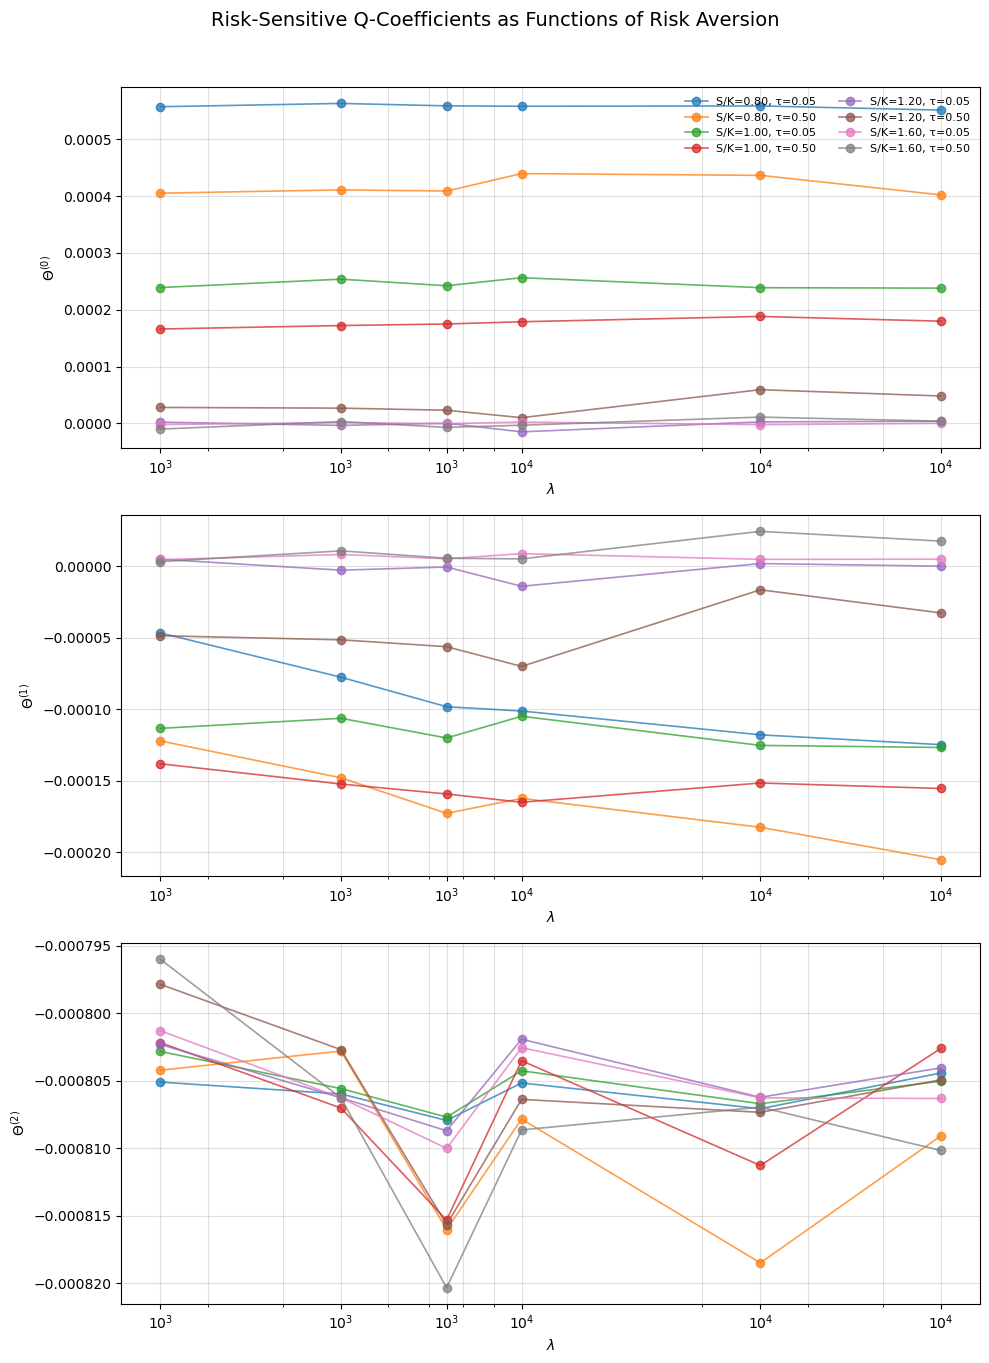

In [50]:
# -------------------------------------------------------------
# Theta0 / Theta1 / Theta2
# Each subplot has its own X-axis
# Force all lambda values to appear as x-ticks
# -------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_all = pd.DataFrame(results_all)

fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 14),
    sharex=False
)

theta_names  = ["Theta0", "Theta1", "Theta2"]
theta_labels = [r'$\Theta^{(0)}$', r'$\Theta^{(1)}$', r'$\Theta^{(2)}$']

# ✅ 强制使用你自己的 lambda grid 作为刻度
xticks = np.array(LAMBDA_GRID)

for ax, theta, label in zip(axes, theta_names, theta_labels):
    for S_over_K in S_OVER_K_GRID:
        for tau in TAU_GRID:
            sub = df_all[
                (df_all["S_over_K"] == S_over_K) &
                (df_all["tau"] == tau)
            ].sort_values("lambda")

            ax.plot(
                sub["lambda"],
                sub[theta],
                marker='o',
                linestyle='-',
                alpha=0.75,
                linewidth=1.2,
                label=f"S/K={S_over_K:.2f}, τ={tau:.2f}"
            )

    # ✅ log scale
    ax.set_xscale("log")

    # ✅ 强制所有 lambda 出现
    ax.set_xticks(xticks)
    ax.set_xticklabels([fr"$10^{{{int(np.log10(x))}}}$" for x in xticks])

    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(label)
    ax.grid(True, which="both", alpha=0.4)

# ✅ legend 只放一个（最上面那张）
axes[0].legend(
    loc="upper right",
    fontsize=8,
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Risk‑Sensitive Q‑Coefficients as Functions of Risk Aversion",
    fontsize=14,
    y=0.97
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


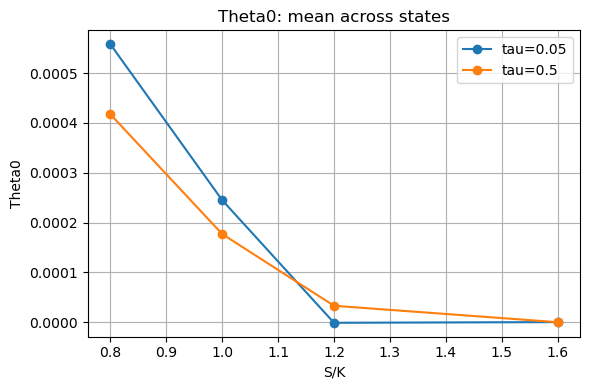

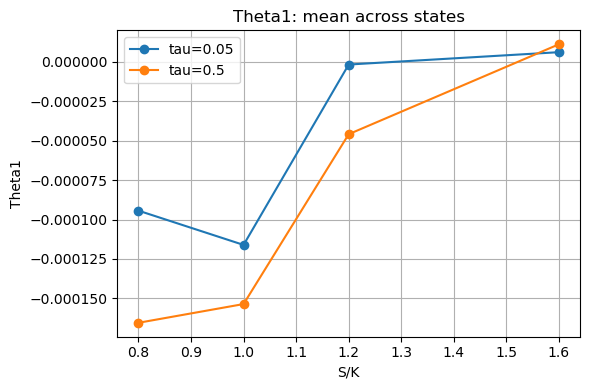

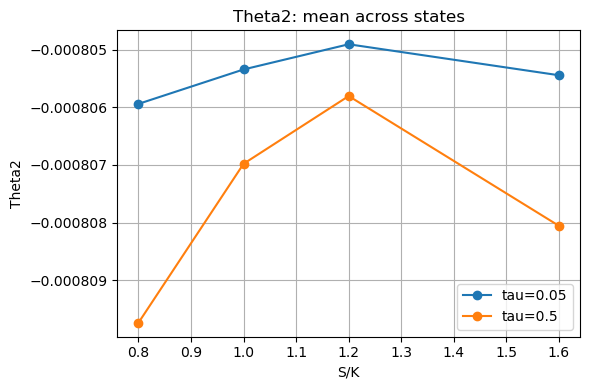

In [51]:
# =============================================================================
# Aggregate plots: Theta mean vs S/K and tau
# =============================================================================

import pandas as pd

df = pd.DataFrame(results)

for theta_name in ["Theta0", "Theta1", "Theta2"]:
    plt.figure(figsize=(6,4))
    for tau in TAU_GRID:
        sub = df[df.tau == tau]
        plt.plot(
            sub.S_over_K,
            sub[f"{theta_name}_mean"],
            'o-',
            label=f"tau={tau}"
        )
    plt.xlabel("S/K")
    plt.ylabel(theta_name)
    plt.title(f"{theta_name}: mean across states")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [52]:
df

,S_over_K,tau,Theta0_mean,Theta0_std,Theta1_mean,Theta1_std,Theta2_mean,Theta2_std
0,0.8,0.05,5.579405e-04,0.000003,-0.000094,0.000026,-0.000806,0.000001
1,0.8,0.50,4.172870e-04,0.000015,-0.000165,0.000026,-0.000810,0.000006
2,1.0,0.05,2.448329e-04,0.000007,-0.000116,0.000009,-0.000805,0.000002
3,1.0,0.50,1.768225e-04,0.000007,-0.000154,0.000008,-0.000807,0.000005
4,1.2,0.05,-1.410004e-06,0.000006,-0.000002,0.000006,-0.000805,0.000002
5,1.2,0.50,3.276198e-05,0.000016,-0.000046,0.000017,-0.000806,0.000005
6,1.6,0.05,2.108115e-08,0.000002,0.000006,0.000002,-0.000805,0.000003
7,1.6,0.50,-1.837909e-07,0.000007,0.000011,0.000008,-0.000808,0.000007


In [53]:
print(df)

   S_over_K   tau   Theta0_mean  Theta0_std  Theta1_mean  Theta1_std  \
0       0.8  0.05  5.579405e-04    0.000003    -0.000094    0.000026   
1       0.8  0.50  4.172870e-04    0.000015    -0.000165    0.000026   
2       1.0  0.05  2.448329e-04    0.000007    -0.000116    0.000009   
3       1.0  0.50  1.768225e-04    0.000007    -0.000154    0.000008   
4       1.2  0.05 -1.410004e-06    0.000006    -0.000002    0.000006   
5       1.2  0.50  3.276198e-05    0.000016    -0.000046    0.000017   
6       1.6  0.05  2.108115e-08    0.000002     0.000006    0.000002   
7       1.6  0.50 -1.837909e-07    0.000007     0.000011    0.000008   

   Theta2_mean  Theta2_std  
0    -0.000806    0.000001  
1    -0.000810    0.000006  
2    -0.000805    0.000002  
3    -0.000807    0.000005  
4    -0.000805    0.000002  
5    -0.000806    0.000005  
6    -0.000805    0.000003  
7    -0.000808    0.000007  


In [54]:
df_all = pd.DataFrame(results_all)

# 选择一个代表性切片
S_OVER_K_TARGET = 0.8
TAU_TARGET = 0.05

sub = df_all[
    (df_all["S_over_K"] == S_OVER_K_TARGET) &
    (df_all["tau"] == TAU_TARGET)
].sort_values("lambda")

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = sub["lambda"].values.reshape(-1, 1)

X = np.log10(sub["lambda"].values).reshape(-1, 1)

print(f"Linear regression at S/K={S_OVER_K_TARGET}, tau={TAU_TARGET}")

for theta in ["Theta0", "Theta1", "Theta2"]:
    y = sub[theta].values

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    print(
        f"[{theta}] slope = {model.coef_[0]:.3e}, "
        f"intercept = {model.intercept_:.3e}, "
        f"R^2 = {r2:.6f}"
    )

Linear regression at S/K=0.8, tau=0.05
[Theta0] slope = -4.992e-06, intercept = 5.780e-04, R^2 = 0.386008
[Theta1] slope = -5.731e-05, intercept = 1.355e-04, R^2 = 0.893641
[Theta2] slope = 3.287e-07, intercept = -8.073e-04, R^2 = 0.013553


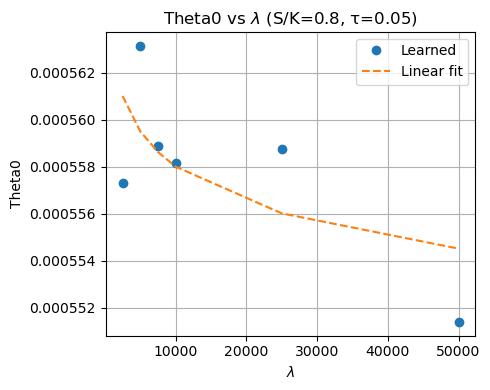

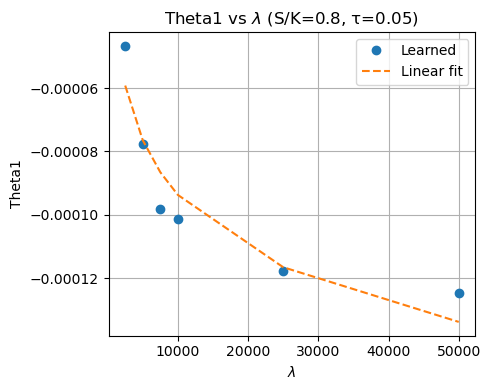

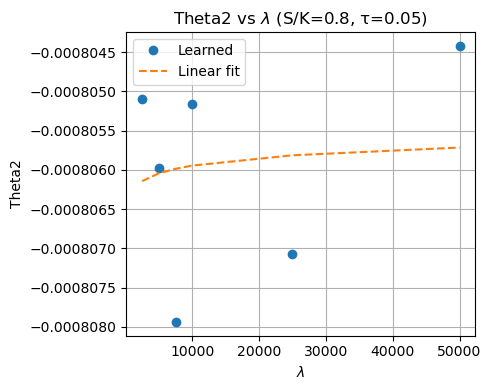

In [56]:
import matplotlib.pyplot as plt

for theta in ["Theta0", "Theta1", "Theta2"]:
    y = sub[theta].values

    model = LinearRegression().fit(X, y)
    y_fit = model.predict(X)

    plt.figure(figsize=(5, 4))
    plt.plot(sub["lambda"], y, "o", label="Learned")
    plt.plot(sub["lambda"], y_fit, "--", label="Linear fit")

    plt.xlabel(r"$\lambda$")
    plt.ylabel(theta)
    plt.title(f"{theta} vs $\\lambda$ (S/K={S_OVER_K_TARGET}, τ={TAU_TARGET})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [57]:
LAMBDA_GRID

[2500.0, 5000.0, 7500.0, 10000.0, 25000.0, 50000.0]

In [58]:
print(df)

   S_over_K   tau   Theta0_mean  Theta0_std  Theta1_mean  Theta1_std  \
0       0.8  0.05  5.579405e-04    0.000003    -0.000094    0.000026   
1       0.8  0.50  4.172870e-04    0.000015    -0.000165    0.000026   
2       1.0  0.05  2.448329e-04    0.000007    -0.000116    0.000009   
3       1.0  0.50  1.768225e-04    0.000007    -0.000154    0.000008   
4       1.2  0.05 -1.410004e-06    0.000006    -0.000002    0.000006   
5       1.2  0.50  3.276198e-05    0.000016    -0.000046    0.000017   
6       1.6  0.05  2.108115e-08    0.000002     0.000006    0.000002   
7       1.6  0.50 -1.837909e-07    0.000007     0.000011    0.000008   

   Theta2_mean  Theta2_std  
0    -0.000806    0.000001  
1    -0.000810    0.000006  
2    -0.000805    0.000002  
3    -0.000807    0.000005  
4    -0.000805    0.000002  
5    -0.000806    0.000005  
6    -0.000805    0.000003  
7    -0.000808    0.000007  
